In [30]:
import os
import sys

current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)

import pandas as pd
from src.models.utils import *
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression



In [31]:
merged_df_path = os.path.join(project_root, "data", "processed", "joined_df.csv")
merged_df = pd.read_csv(merged_df_path, encoding='utf-8')
power_plants = merged_df[['name', 'code']].drop_duplicates()
power_plants = power_plants[power_plants['code'].str.startswith("G")]


In [32]:
merged_df.shape

(632851, 9)

In [33]:
merged_df.columns

Index(['Unnamed: 0', 'name', 'code', 'date', 'hour', 'temperature',
       'sen_temperature', 'generation', 'is_good_peak'],
      dtype='object')

In [34]:
x = merged_df[(merged_df['name'] == "پرند") & (merged_df['is_good_peak'] == 3)]

In [35]:
x.dropna(inplace=True)
x.shape

C:\Users\S.H.Jasbi\AppData\Local\Temp\ipykernel_4208\4132816014.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x.dropna(inplace=True)


(10973, 9)

In [36]:
merged_df2 = merged_df[merged_df['is_good_peak'] >= 3]
merged_df2 = merged_df2[merged_df2[('sen_temperature')] >= 5]
merged_df2 = merged_df2[merged_df2[('sen_temperature')] < 50]
merged_df2 = merged_df2[merged_df2['generation'] <= 175]
merged_df2 = merged_df2[merged_df2['generation'] > 0]


In [54]:
errors = []


def show_line_max(i):
    row = power_plants.iloc[i]
    name = row['name']
    code = row['code']
    print(name, code)
    filtered_df = merged_df2[(merged_df2['name'] == name) & (merged_df2['code'] == code)]
    senstemps = filtered_df['sen_temperature'].values
    gens = filtered_df['generation'].values

    zipped = list(zip(senstemps, gens))
    zipped.sort(key=lambda x: x[0])
    senstemps_sorted, gens_sorted = zip(*zipped)
    senstemps_sorted = np.array(senstemps_sorted)
    gens_sorted = np.array(gens_sorted)

    k = 10
    n = len(senstemps_sorted)
    tuples = []
    for i in range(0, n, k):
        end_idx = min(i + k, n)
        temp_tmp_list = senstemps_sorted[i: end_idx]
        gens_tmp_list = gens_sorted[i: end_idx]
        tuples.append((temp_tmp_list.mean(), max(gens_tmp_list)))

    # hist, bin_edges = np.histogram(senstemps, bins=101)
    # group_indices = np.digitize(senstemps, bin_edges) - 1
    # tuples = []
    # for g in np.unique(group_indices):
    #     mask = group_indices == g
    #     tuples.append((senstemps[mask].mean(), max(gens[mask])))

    X = np.array([a for a, b in tuples])
    y = np.array([b for a, b in tuples])
    model = LinearRegression()
    X = X.reshape(-1, 1)
    model.fit(X, y)
    y_pred = model.predict(X)
    plt.scatter(senstemps, gens, s=1, alpha=0.2)
    plt.plot(X, y_pred, color="red")
    plt.scatter(X, y, s=3)
    error = compute_relative_rmse(y_pred, y)
    print(error)
    errors.append(error)
    plt.show()


In [55]:
bad_units = [2, 8, 9, 10, 11, 17, 19, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 40, 41]
good_units = [x for x in range(46) if x not in bad_units]

پرند G16
0.8603009105660719


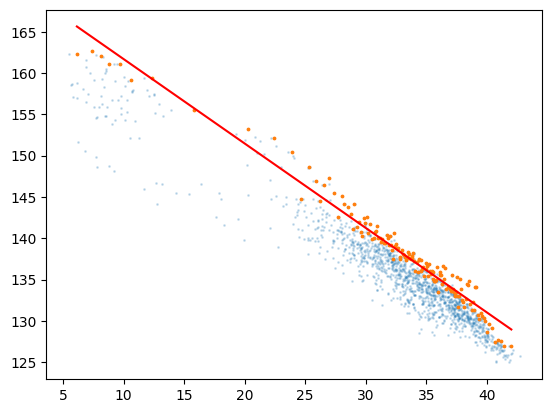

پرند G14
0.7168085512144312


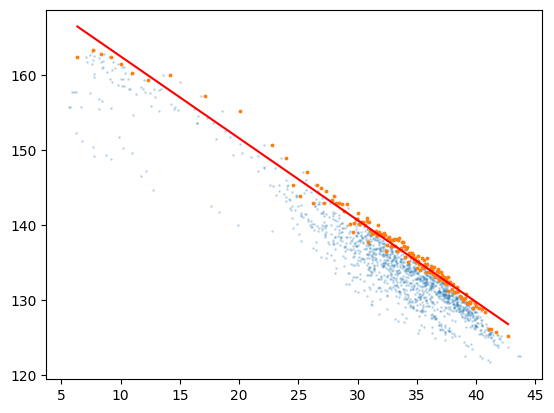

پرند G12
1.8793543789108926


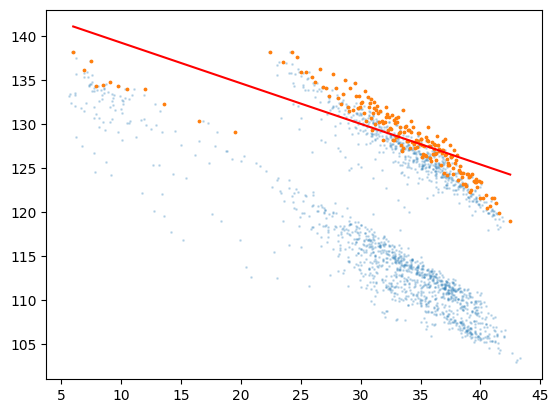

پرند G13
0.6542419770208162


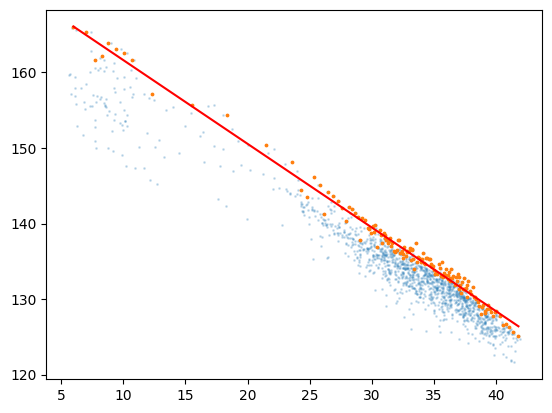

پرند G11
0.8480531612706008


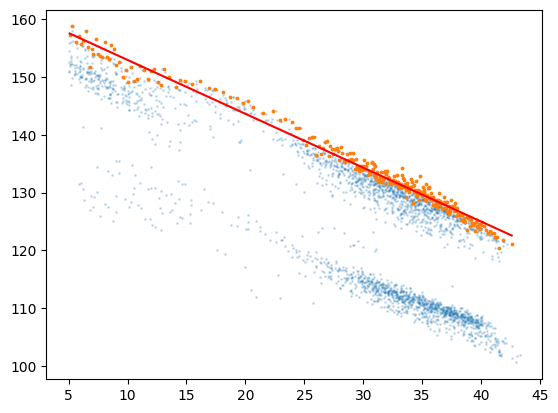

پرند G15
0.6373674472747046


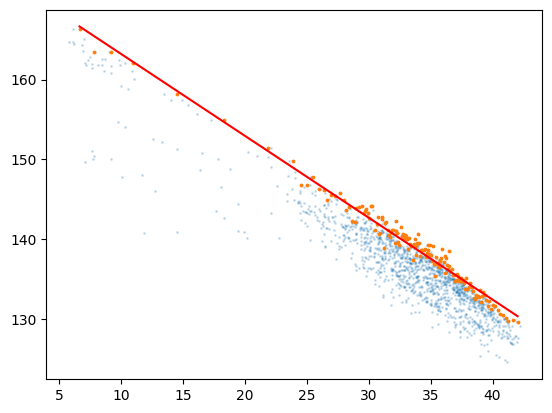

شهدای پیروز - بهبهان G12
0.9129338936826964


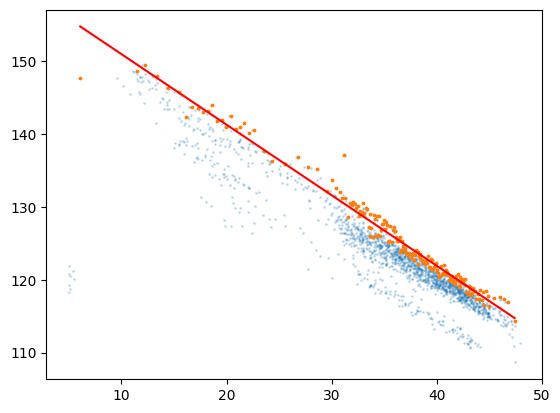

شهدای پیروز - بهبهان G11
1.0556936696224417


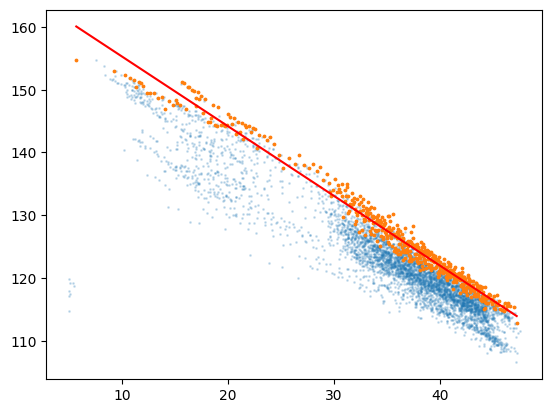

جنوب اصفهان - چهلستون G15
0.0


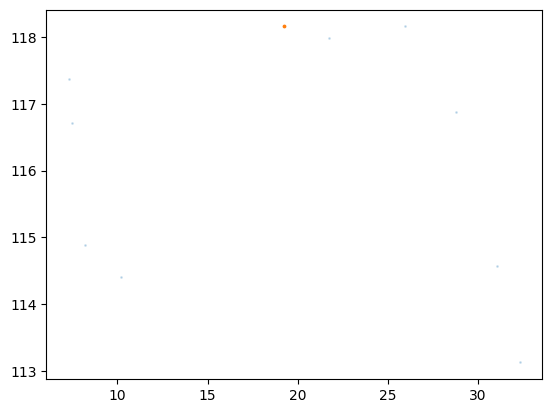

جنوب اصفهان - چهلستون G14
0.0


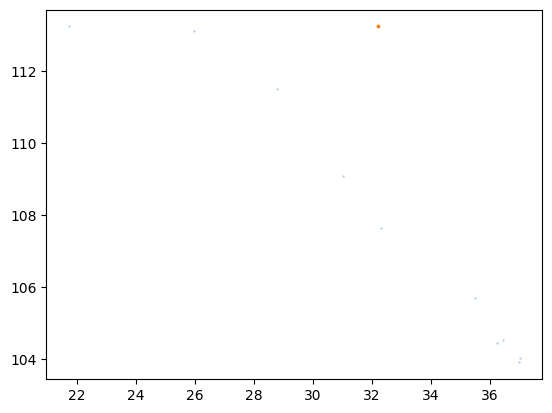

جنوب اصفهان - چهلستون G13
0.0


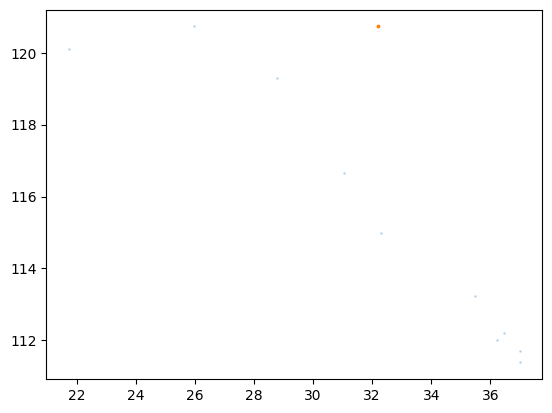

جنوب اصفهان - چهلستون G12
0.0


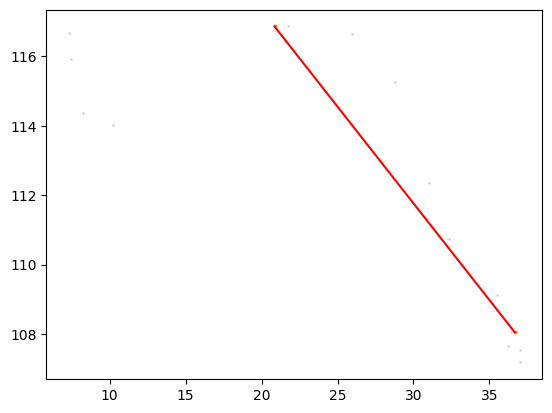

جنوب اصفهان - چهلستون G11
1.0358334330206282


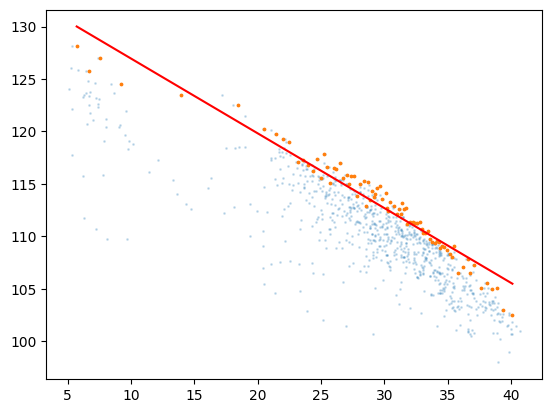

سبلان G16
0.6419730635970854


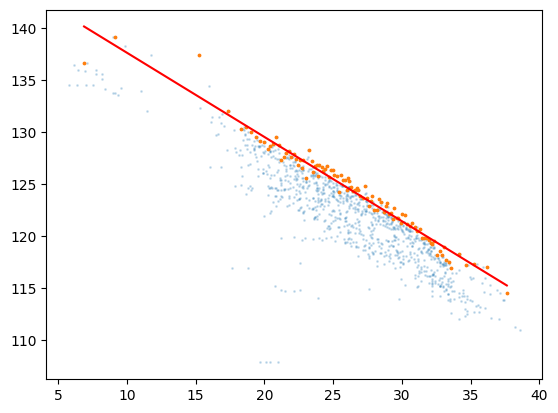

سبلان G14
0.6704385825467036


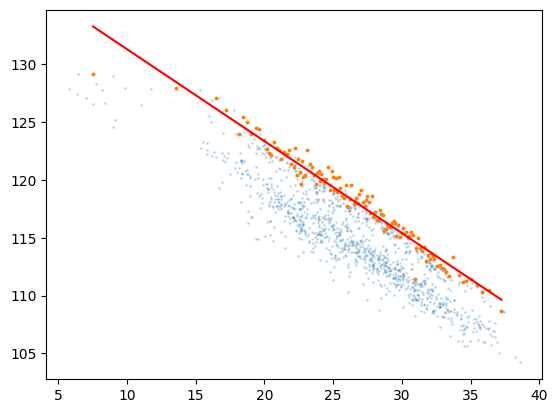

سبلان G13
0.9344406389691772


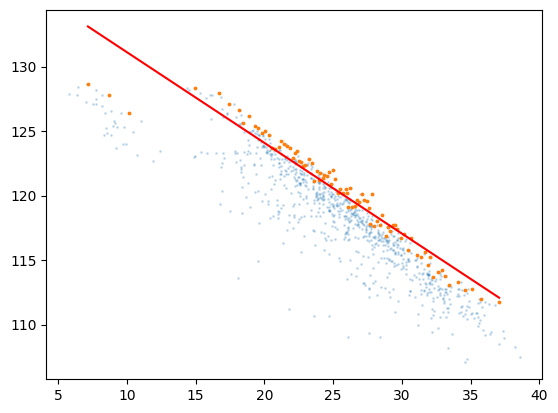

سبلان G15
0.5345600034159457


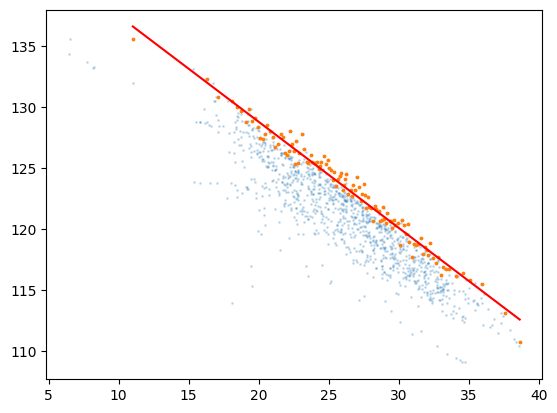

جنوب اصفهان - چهلستون G16
0.0


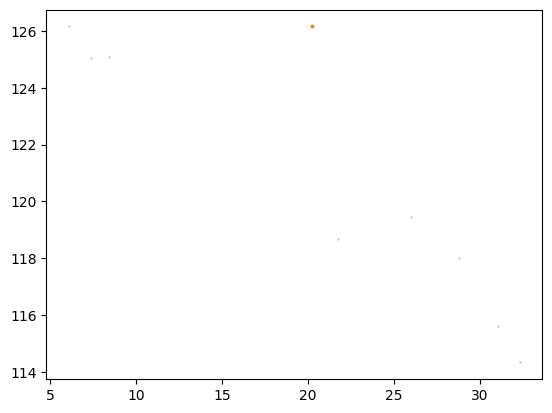

سبلان G12
0.7033445905182155


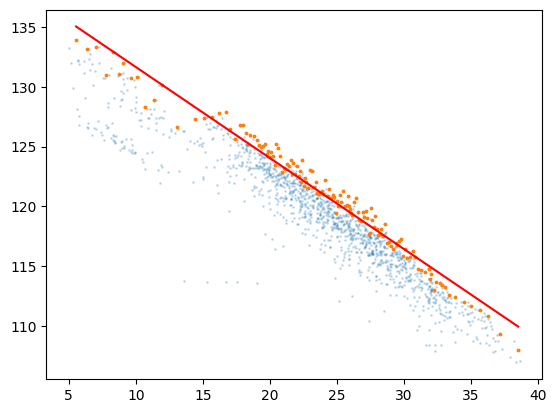

سبلان G11
0.972405480597136


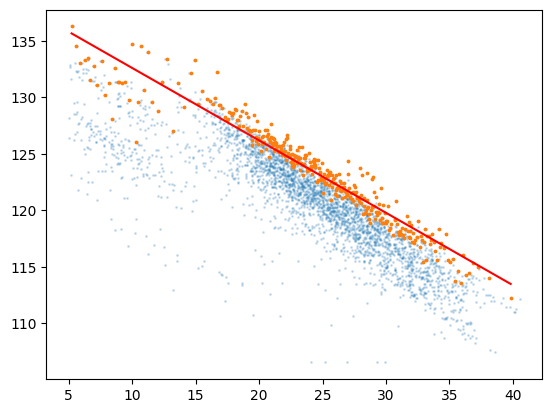

سیکل ترکیبی ارومیه G14
0.7126631988937028


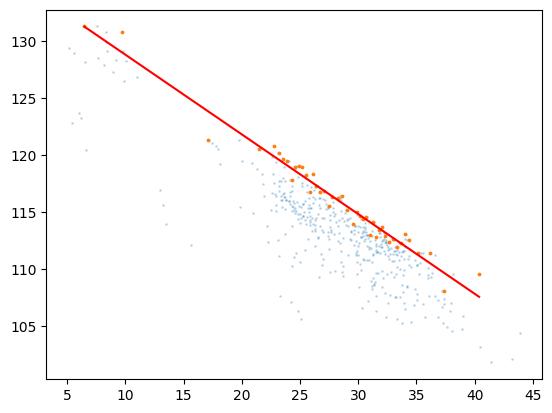

سیکل ترکیبی ارومیه G13
0.8550989037145802


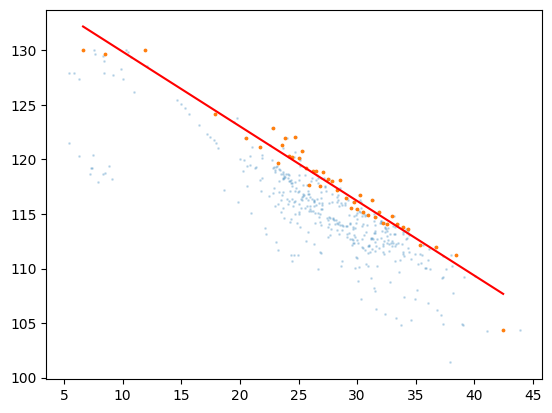

سیکل ترکیبی ارومیه G12
1.1003537743635352


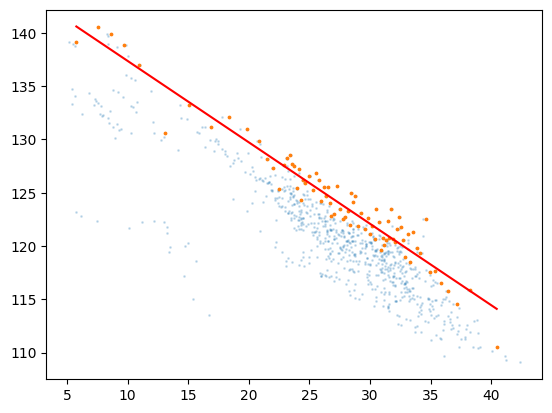

سیکل ترکیبی ارومیه G15
0.7141539997553614


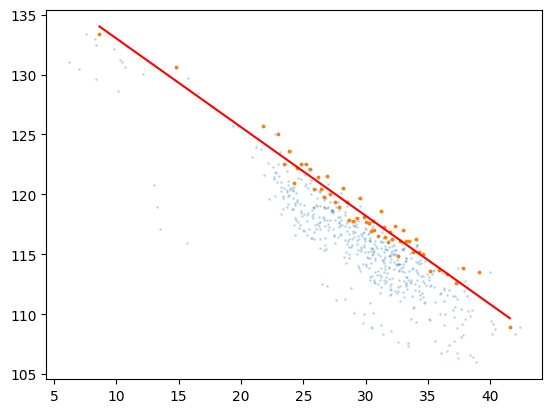

سیکل ترکیبی ارومیه G16
0.7539182478405002


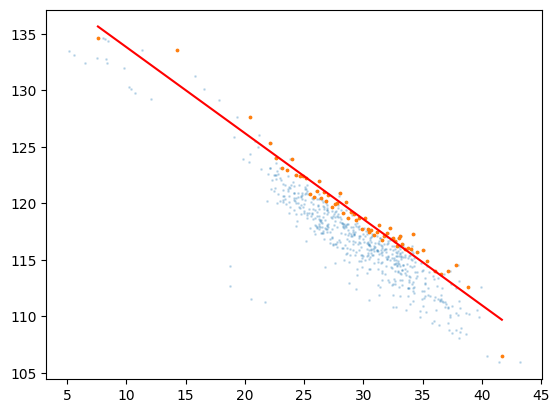

سیکل ترکیبی ارومیه G11
1.0062892928759706


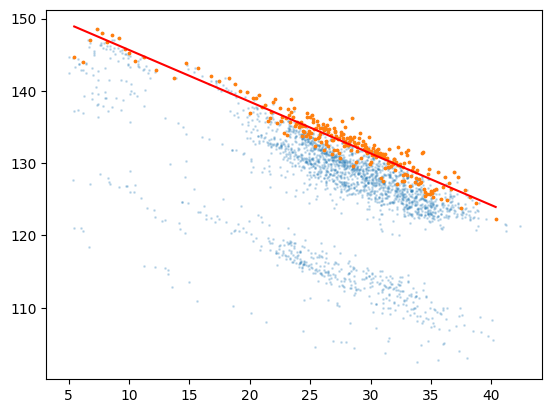

سیکل ترکیبی یزد G12
2.6970739753729225


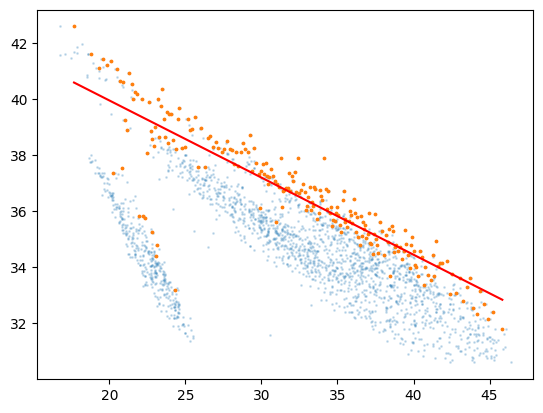

سیکل ترکیبی یزد G11
2.490944945785574


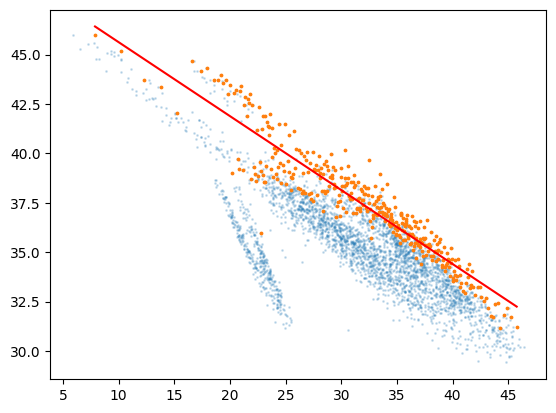

سیکل ترکیبی شیروان G16
2.5236333021445265


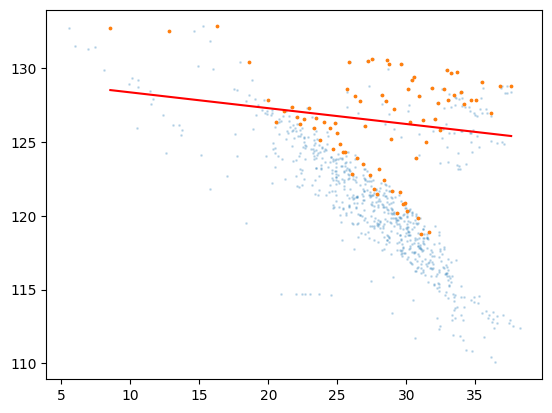

سیکل ترکیبی شیروان G11
3.19295084699193


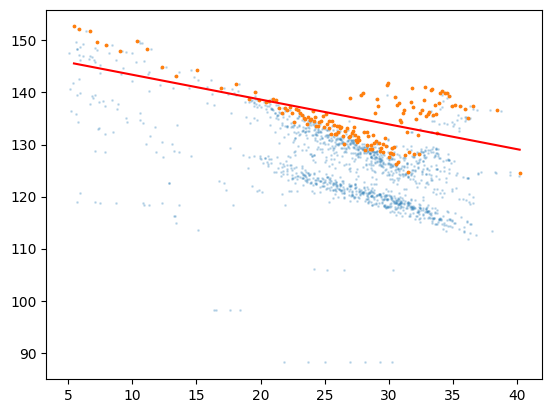

سیکل ترکیبی شیروان G15
2.0796323264328636


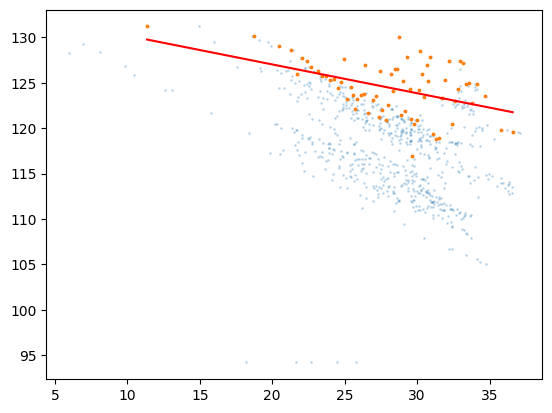

سیکل ترکیبی شیروان G12
2.541810259556266


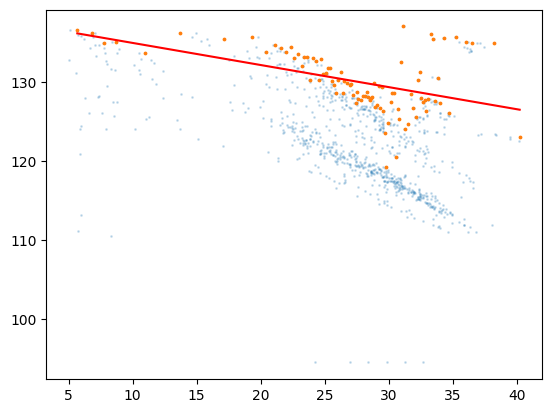

سیکل ترکیبی شیروان G14
2.44495345220705


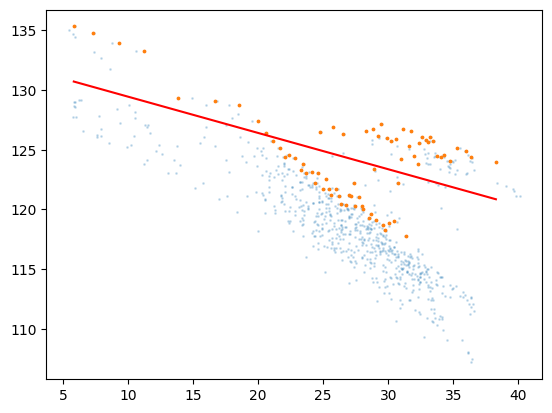

سیکل ترکیبی شیروان G13
2.787010775963799


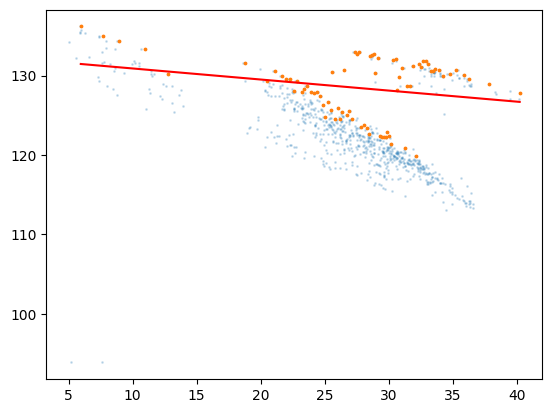

عسلویه G15
1.5923236879700244


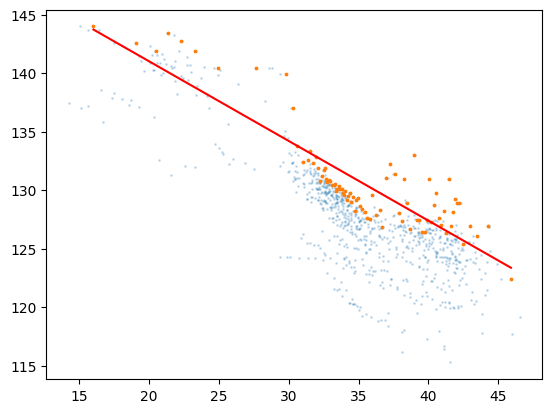

عسلویه G16
1.5105781037943495


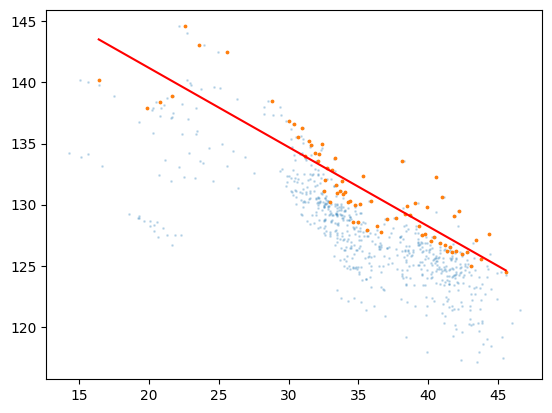

عسلویه G14
1.583771431777161


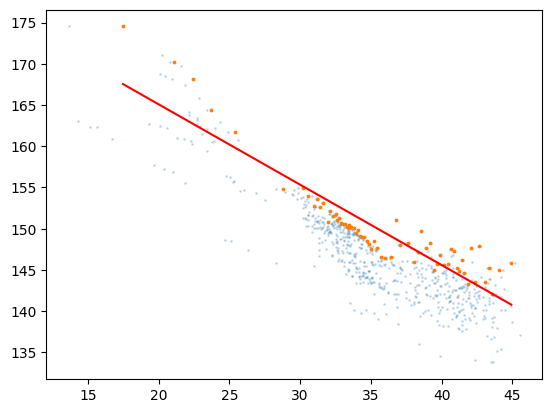

عسلویه G13
1.5225750309308506


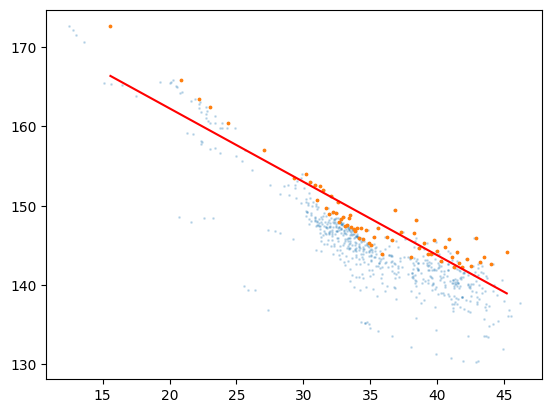

حافظ G16
0.4770715282258222


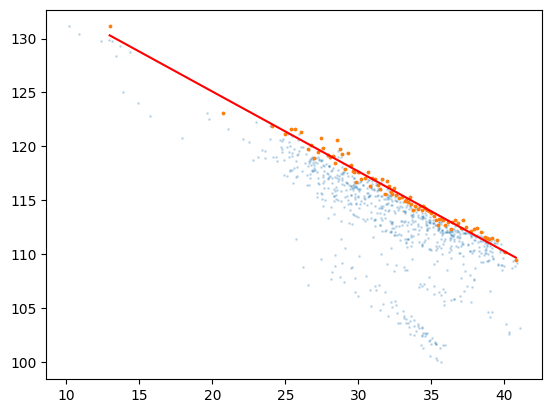

حافظ G11
0.7156730462778033


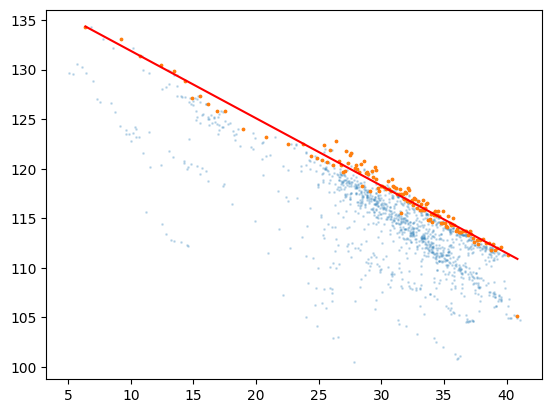

عسلویه G11
1.884789054597892


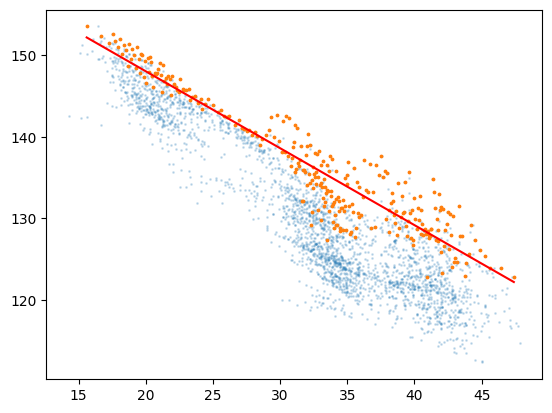

عسلویه G12
2.0399223264011637


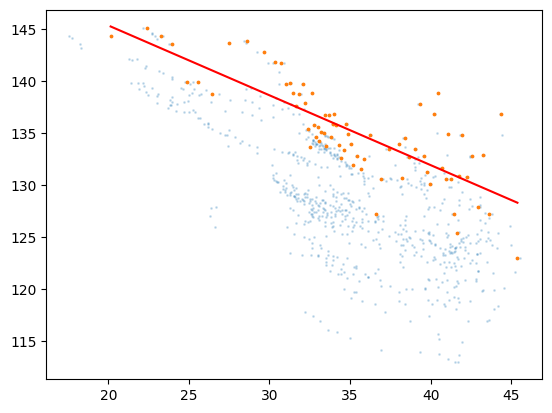

حافظ G15
0.4733508235487454


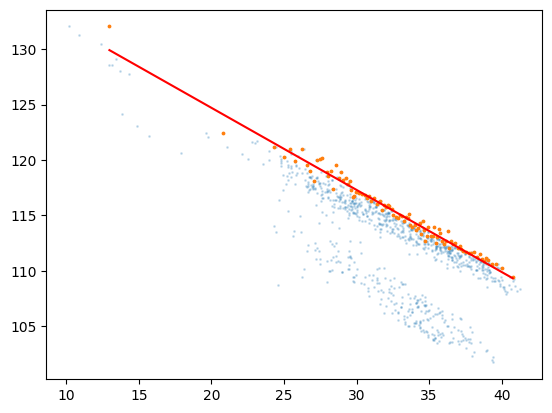

حافظ G12
0.4797908839293376


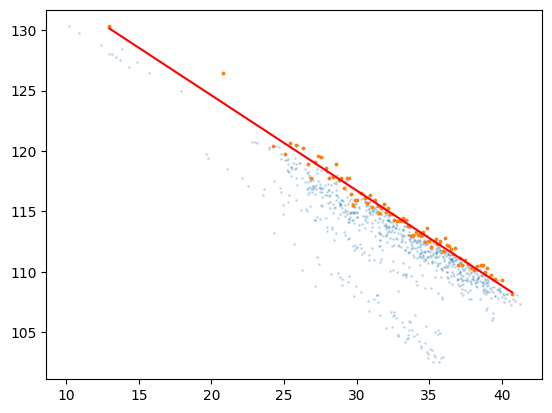

حافظ G14
0.469890147762867


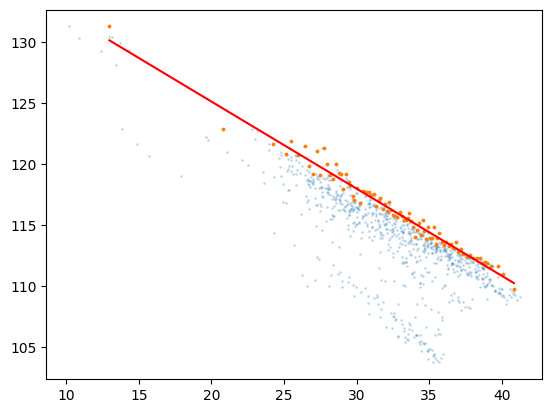

حافظ G13
0.6146668827514012


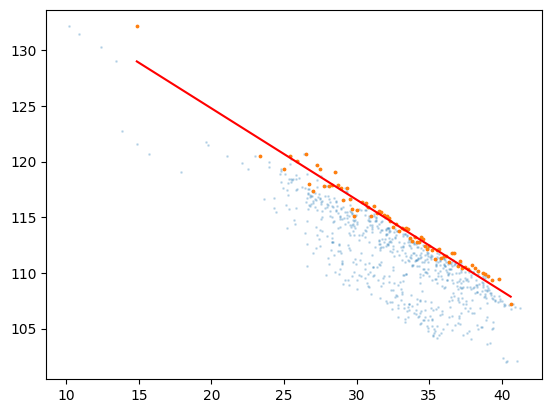

In [56]:
for i in range(len(power_plants)):
    show_line_max(i)

In [ ]:



for i in good_units:
    show_line_max(i)

In [ ]:
for i in bad_units:
    show_line_max(i)

In [57]:
np.mean(errors)

np.float64(1.1374486963498598)

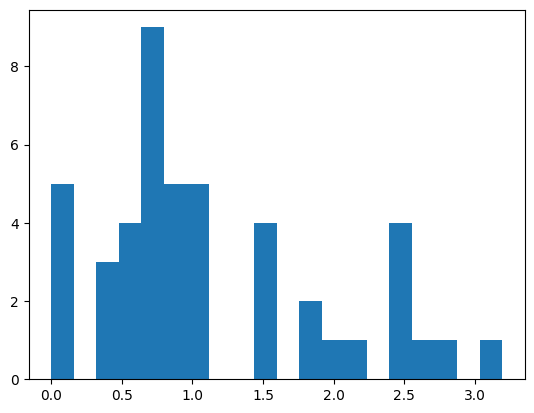

In [58]:
plt.hist(errors, bins=20)
plt.show()

In [ ]:
errors = np.array(errors)
indices = [idx for idx in range(len(errors)) if errors[idx] > 2]
indices = np.array(indices)

In [ ]:
print(indices)
bad_units = np.array(bad_units)
print(bad_units)